# Single-tile pipeline: composite → inference → kriging

This notebook runs the **full pipeline for one Sentinel-2 tile** by importing and calling the
repository's actual functions (no subprocess, no fake data):

1. **Composite** — build the yearly S2 median composite for the tile (`data_prep/composite.py`).
2. **Inference** — run the BioFiLM ensemble to get the dense AGB + STD map (`inference/inference_composite.py`).
3. **Kriging** — fit the GPR calibration on GEDI residuals and write the corrected map (`kriging/kriging.py`).

**Prerequisites**
- The conda env from `environment.yml` (PyTorch, GPyTorch, rasterio, geopandas, …) and a **GPU** for inference/kriging.
- `DATA_ROOT` pointing at your data, laid out as in `DATA.md` (S2 products, ALOS DEM, GEDI L4A, the tile index shapefile, and the BioFiLM checkpoints).
- Weights & Biases is **not** required (logging is a no-op unless `USE_WANDB=true`).

Each step below builds the same argument list the command-line scripts use, then calls the
function directly. Edit the configuration cell and run top to bottom.


In [2]:
import os, sys
# Make the repo importable (or `pip install -e .` and drop these two lines).
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

# Pick the environment config (configs/<AGBD_ENV>.yaml) that defines DATA_ROOT and all
# data paths. setdefault lets a value already exported in your shell win; otherwise we
# default to pf-pc28. Must be set BEFORE importing config. Change to 'euler' (or your own
# configs/<name>.yaml) as needed.
os.environ.setdefault('AGBD_ENV', 'pf-pc28')

from config import DATA_ROOT          # data paths come from configs/<AGBD_ENV>.yaml
print('AGBD_ENV =', os.environ['AGBD_ENV'])
print('DATA_ROOT =', DATA_ROOT)

# ---- Configuration for this run (edit me) ----
TILE        = '30NXM'                 # MGRS Sentinel-2 tile id
YEAR        = 2020
ARCH        = 'nico_film'             # BioFiLM
ENS_MODELS  = ['17997535-1', '17997535-2', '17997535-3']   # the 3 ensemble checkpoints

# Paths (see DATA.md). These follow the default DATA_ROOT layout.
PATH_S2          = f'{DATA_ROOT}/S2_L2A'
PATH_PREDICTIONS = f'{DATA_ROOT}/EcosystemAnalysis/Models/Biomes/predictions'
PATH_GEDI        = f'{DATA_ROOT}/GEDI/L4A_California_Cuba_Paraguay_UnitedRepublicofTanzania_Ghana_Austria_Greece_Nepal_ShaanxiProvince_NewZealand_FrenchGuiana-indexed.gpkg'
PATH_GEOMETRIES  = f'{DATA_ROOT}/BiomassDatasetCreation/Data/download_Sentinel/sentinel_2_index_shapefile.shp'
PATH_DEM         = f'{DATA_ROOT}/ALOS'
PATH_KRIGING     = f'{DATA_ROOT}/EcosystemAnalysis/Models/Biomes/kriging'

AGBD_ENV = pf-pc28
DATA_ROOT = /scratch3/gsialelli


## 1. Sentinel-2 composite

Builds the yearly median composite for the tile from the downloaded S2 L2A products.
Adjust `--method`/`--mode` to your setup (see `data_prep/composite.py` `_parser`).


In [4]:
from data_prep.composite import composite

composite([
    '--tile_name', TILE,
    '--path_s2', PATH_S2,
    '--method', 'median',
    '--mode', 'all',
    '--year', str(YEAR),
    '--path_txt', '',
    '--clouds', 'true',
    '--calculate_coverage', 'false',
    '--force', 'false',
])


Found 8 products.
Unzipping S2A_MSIL2A_20201227T102431_N9999_R065_T30NXM_20240422T080438...
Unzipping S2B_MSIL2A_20200127T102209_N9999_R065_T30NXM_20240422T121237...
Unzipping S2B_MSIL2A_20200206T102109_N9999_R065_T30NXM_20240422T081341...
Unzipping S2B_MSIL2A_20200526T101559_N9999_R065_T30NXM_20240422T121415...
Unzipping S2B_MSIL2A_20200127T102209_N0500_R065_T30NXM_20230428T164032...
Unzipping S2A_MSIL2A_20200112T102401_N0500_R065_T30NXM_20230424T091251...
Unzipping S2A_MSIL2A_20200102T102421_N0500_R065_T30NXM_20230425T023320...
Unzipping S2B_MSIL2A_20200804T101559_N0500_R065_T30NXM_20230403T073925...
Band B02 already exists, skipping...
Band B03 already exists, skipping...
Band B04 already exists, skipping...
Band B08 already exists, skipping...
Band B05 already exists, skipping...
Band B06 already exists, skipping...
Band B07 already exists, skipping...
Band B8A already exists, skipping...
Band B11 already exists, skipping...
Band B12 already exists, skipping...
Band SCL already exi

## 2. Inference (dense AGB + STD)

Runs the BioFiLM ensemble on the composite to produce the dense AGB prediction and its
per-pixel ensemble standard deviation — the inputs kriging calibrates. Requires the checkpoints
under `DATA_ROOT/.../weights/` (see DATA.md) and a GPU.


In [3]:
from inference.inference_composite import run_inference

# Paths are no longer passed here: inference_composite sources them from
# configs/<env>.yaml via src/config.py (selected by hostname or $AGBD_ENV).
run_inference([
    '--year', str(YEAR),
    '--models', *ENS_MODELS,
    '--arch', ARCH,
    '--tile_name', TILE,
    '--method', 'median',
    '--std', 'true',
    '--saving_dir', PATH_PREDICTIONS,
])


Loading input...
Unzipping 30NXM_2020_composite_median.zip...
done!
Loading input took 438.6988277435303 seconds.
Starting prediction...
done!


Visualize the predictions.

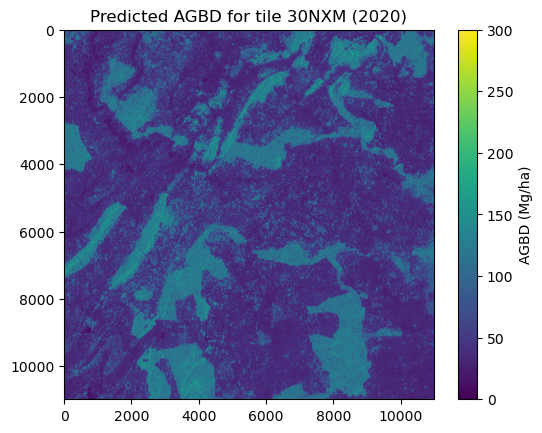

In [7]:
import rasterio 
import matplotlib.pyplot as plt

# Visualize the predictions
path_to_pred = f'{PATH_PREDICTIONS}/{ARCH}/{"_".join(ENS_MODELS)}/{TILE}_{YEAR}_composite.tif'
with rasterio.open(path_to_pred) as src:
    pred = src.read(1)
plt.imshow(pred, vmin=0, vmax=300)
plt.colorbar(label='AGBD (Mg/ha)')
plt.title(f'Predicted AGBD for tile {TILE} ({YEAR})')
plt.show()


## 3. Kriging calibration

Fits the per-tile GPR on the GEDI residuals and writes the calibrated map. The hyper-parameters
below mirror the recommended configuration (paper Table 2, config VII; same values as
`src/kriging/kriging.sh`).


In [3]:
from kriging.kriging import main as run_kriging

kriging_args = {
    's2_tile': TILE, 'year': YEAR, 'arch': ARCH,
    'path_predictions': PATH_PREDICTIONS, 'path_gedi': PATH_GEDI,
    'path_geometries': PATH_GEOMETRIES, 'path_dem': PATH_DEM, 'path_kriging': PATH_KRIGING,
    'model_name': f'local-{TILE}', 'composites': 'true',
    # split
    'test_holdout': 0.3, 'val_holdout': 0.2, 'stripe_size': 50,
    'max_split_diff': 15, 'max_tries': 100, 'seed': 10,
    # auxiliary variables / features
    'aux': 'STD', 'pred_vals': 'true',
    'extra_features': ['mean_25', 'std_25', 'cv_25', 'lr_25'],
    # normalisation
    'norm_aux': 'min_max', 'norm_coords': 'true', 'norm_res': 'true', 'coords': 'true',
    # GP / kernel (Matern 1/2, dynamic x-y lengthscales)
    'matern_nu': 0.5, 'x_lengthscale': 'dynamic', 'y_lengthscale': 'dynamic', 'fix_x_y': 'true',
    'z_aux_lengthscale': 0.1, 'z_pred_lengthscale': 0.1, 'eft_lengthscale': 0.1,
    'outputscale': 1.0, 'gaussian_noise': 0.1, 'learned_noise': 1.0,
    # optimisation / footprints
    'lr': 1e-2, 'num_iterations': 1000, 'pos_loss': 'true', 'patience': 50, 'min_delta': 0.001,
    'max_train_footprints': 25000, 'mem_max_footprints': 25000, 'ref_model': '',
    # behaviour / outputs
    'ood': 'false', 'agb': 'false', 'COMPUTE_VAR': 'true', 'SAVE': 'true', 'SAVE_preds': 'true',
    # in this example, we set 'ood' to False because it needs a basic config first
}

# Expand the dict into the argv list the parser expects.
argv = []
for k, v in kriging_args.items():
    argv.append(f'--{k}')
    argv += [str(x) for x in (v if isinstance(v, list) else [v])]
argv += ['--ens_models', *ENS_MODELS]

run_kriging(argv)


Loading data...
Computing extra features...
done!
Number of footprints: 4501
dynamic dynamic
Calculating dynamic lengthscales based on the maximum distance to footprint.
new lengthscales before scaling: 4500.0 4000.0
New lengthscales: x=0.4098360655737705, y=0.36429872495446264

Number of footprints before groupby: 4500
Number of footprints after groupby: 3544


Overall RMSE: 72.50671732909733

Loading existing splits.
1985 487 1072
    RMSEs: 74.63 (train) | 72.70 (validation) | 68.41 (test)
    Normalizing the coordinates with min-max scaling
Train/val/test sizes: 1991 | 490 | 1075
Residuals normalizations values: mean = -6.9157, std = 74.3122
    Training the model...
Checking trainable parameters:
likelihood.noise_covar.raw_noise True
mean_module.raw_constant True
covar_module.raw_outputscale True
covar_module.base_kernel.raw_lengthscale True
    Iter 0/1000 - Train Loss: 1.492   Val Loss: 1.340   lengthscale: [[0.40983605 0.3642987  0.09905265 0.09905265 0.09905265 0.09905265
  0.

## 4. Inspect the corrected map

Kriging writes the calibrated raster under `PATH_KRIGING` (and a `.pt`/`.ckpt` with the fitted
GP + its config). Load and plot pre- vs post-calibration below (adjust the filenames to match
what your run produced).


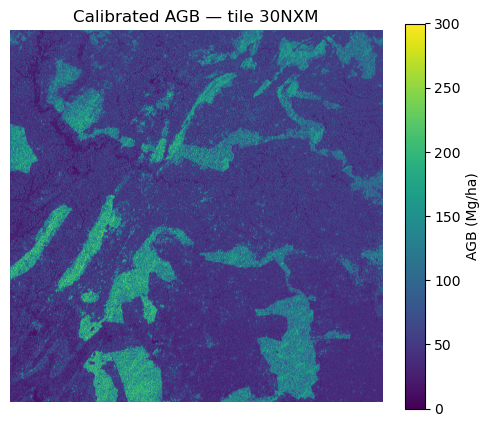

In [5]:
import rasterio, numpy as np, matplotlib.pyplot as plt

# Example: read the corrected output raster (update the path to your saved file).
model_str = '_'.join(ENS_MODELS)
out_tif = f'{PATH_KRIGING}/predictions/{ARCH}/{TILE}/{YEAR}/{model_str}/kriging-local-{TILE}.tif'
with rasterio.open(out_tif) as src:
    corrected = src.read(1)

plt.figure(figsize=(6, 5))
plt.imshow(corrected, cmap='viridis', vmin=0, vmax=300)
plt.colorbar(label='AGB (Mg/ha)')
plt.title(f'Calibrated AGB — tile {TILE}'); plt.axis('off'); plt.show()
